# Installing needed packages for 2m_miso

In [1]:
from miso.hist_features import get_features
from miso.utils import *
from miso import Miso
from PIL import Image
import pandas as pd
import numpy as np
import scanpy as sc
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
Image.MAX_IMAGE_PIXELS = None
Image.MAX_IMAGE_PIXELS = None
import torch
import random

## Set up main run method (cpu/gpu)

**Parameters:** <br>
random.seed(seed=None) - Reseed the singleton RandomState instance. <br>
torch.manual_seed(seed) - Sets the seed for generating random numbers on all devices. Returns a torch.Generator object. <br>
random.seed(a=None, version=2) - Initialise the random number generator. <br>

torch.cuda.manual_seed(seed) - Set the seed for generating random numbers for the current GPU. <br>
torch.cuda.get_device_name(device=None) - Get the name of a device. <br>

In [2]:
seed=100
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    device = 'cuda'
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("CUDA is available. GPU:", torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print("CUDA is not available. Using CPU.")

CUDA is not available. Using CPU.


## Reading joint Spatialmeta data (Y7_T_joint)

**Parameters:** <br>
scanpy.read_h5ad(filename) - Read .h5ad-formatted hdf5 file.

In [3]:
os.chdir('miso_tutorial_data')

joint_adata_pp = sc.read_h5ad("../SpatialMETA/data/Y7_T_joint.h5ad")

print(joint_adata_pp)
print(joint_adata_pp.uns["spatial"].keys())

lib = list(joint_adata_pp.uns["spatial"].keys())[0]
print(joint_adata_pp.uns["spatial"][lib].keys())

print(joint_adata_pp.uns["spatial"][lib]["images"].keys())

AnnData object with n_obs × n_vars = 1914 × 37703
    obs: 'x_coord', 'y_coord', 'spot_name', 'total_intensity', 'mean_intensity', 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes'
    var: 'name', 'type'
    uns: 'spatial'
    obsm: 'spatial'
dict_keys(['Y7_T'])
dict_keys(['images', 'metadata', 'scalefactors'])
dict_keys(['hires', 'lowres'])


## Load data and perform necessary preprocessing
Preprocessing provided by MISO. The only requirement is that the dataset be split into each modality. 

**Parameters:** <br>
preprocess(adata, modality) - Takes in a specific dataset and modality type, then preprocesses and returns the usable dataset. 

In [4]:
rna = joint_adata_pp[:, joint_adata_pp.var["type"] == "ST"]
rna = preprocess(rna,modality='rna')
print(rna.shape)

protein = joint_adata_pp[:, joint_adata_pp.var["type"] == "SM"]
protein = preprocess(protein,modality='protein')
print(protein.shape)

(1914, 16615)
(1914, 1299)


## Running, training and saving the results of the MISO model 
If using a subset of modality-specific terms, the "ind_views" parameter should be a list with values that are entries to the indices of the modalities to be included, e.g.,  ind_views=[0,2] if including RNA and image features. <br>
If using a subset of interaction terms, the "combs" parameter should be a list of tuples with entries to the indices of the modalities for each interaction, e.g. combs = [(0,1),(0,2)] if including the RNA-protein and RNA-image interaction terms. <br>

**Parameters:** <br>
Miso(features, ind_views='all', combs='all', sparse=False, neighbors = None, device='cpu') - This is the step for preparing the multiple feature matrices for a learning model (model.train())<br><br>
model.train(self) - This step creates one neural network per modality (RNA, protein). Then learns the interactions between the features in both neural networks and condenses the final results into a single embedding matrix. <br><br>
np.save(file, arr, allow_pickle=True) - Save an array to a binary file in NumPy .npy format.

In [5]:
model = Miso(
    [rna,protein],
    ind_views='all',
    combs='all',
    sparse=False,
    device=device)

model.train()

np.save('emb.npy', model.emb)

Training network for modality 1:   0%|          | 0/1000 [00:00<?, ?it/s]

Training network for modality 2:   0%|          | 0/1000 [00:00<?, ?it/s]

## Set up for the clustering on the histology image
This step first reads and stores the hires image from the joint dataset. Then the scaling factors of the correct image are read and stored. After that the coordinates of the spots are scaled to the image size for correct placement. The final step is storing all the spot data into a locs (location) pandas dataframe. <br>

**Parameters:** <br>
pd.DataFrame(data=None, index=None, columns=None, dtype=None, copy=None) - Two-dimensional, size-mutable, potentially heterogeneous tabular data.

In [6]:
im = joint_adata_pp.uns["spatial"][lib]["images"]["hires"]

scale = (
    joint_adata_pp.uns["spatial"][lib]
    ["scalefactors"]["tissue_hires_scalef"]
)

coords = joint_adata_pp.obsm["spatial"] * scale

locs = pd.DataFrame(
    {
        "1": 1,                    # all spots in tissue
        "2": np.arange(len(coords)),
        "3": np.arange(len(coords)),
        "4": coords[:,1],          # row coordinate
        "5": coords[:,0],          # column coordinate
    },
    index=joint_adata_pp.obs_names
)

## Final histology image with clustering results
First the clusters are calculated by k-means. Then the clusters, spot coordinates, histology image, scale and size of dots (spots) are given to plot_on_histology. This method is from MISO and uses matplotlib to create the final image. <br>

**Parameters:**<br>
model.cluster(n_clusters) - Takes in a set amount of clusters. The method used is K-means clustering. This method returns the designated clusters in an array. <br><br>
plot_on_histology(clusters, locs, im, scale, s=10) - Takes in an array of clusters, the coordinates of spots, the histology image, the set scale and the size of the dots (spots). This method returns a histology image with clustered spots laid on top. 


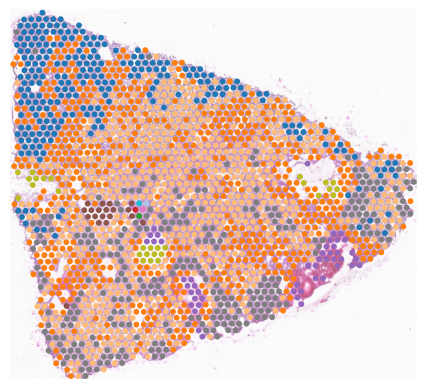

In [7]:
clusters = model.cluster(n_clusters=12)
scale = 1.0
plot_on_histology(clusters,locs,im,scale,s=10)

## Benchmarking metrics

### Setup

In [ ]:
from multi_benmark_function_miso import (
    compute_CHAOS, compute_PAS,
    marker_score,
    compute_ARI, compute_NMI,
    compute_ASW,
    compute_clisi_graph,
    calculate_gene_specificity,
    logistic_regression_feature_importance,
    calculate_mutual_information
)
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity

PRED_KEY = 'VAE_clusters_latent10'
EMB_KEY   = 'X_emb'
GT_KEY    = 'pathological_annotation'


ModuleNotFoundError: No module named 'squidpy'

Add ground truth label to data

In [2]:
gt_adata = sc.read_h5ad("data/06_spatialmeta_groundtruth/adata_joint_Y7_T_hvf2800.h5ad")

# Build mapping on array_row + array_col instead
gt_annotation = gt_adata.obs[['array_row', 'array_col', 'pathological_annotation']].copy()
gt_annotation['grid_key'] = (gt_annotation['array_row'].astype(str) + '_' + 
                              gt_annotation['array_col'].astype(str))
gt_annotation = gt_annotation.set_index('grid_key')

# Same key on your data
joint_adata_pp.obs['grid_key'] = (joint_adata_pp.obs['array_row'].astype(str) + '_' + 
                                joint_adata_pp.obs['array_col'].astype(str))

# Transfer annotation
joint_adata_pp.obs['pathological_annotation'] = (
    joint_adata_pp.obs['grid_key']
               .map(gt_annotation['pathological_annotation'])
)
joint_adata_pp.obs['pathological_annotation'] = (
    joint_adata_pp.obs['pathological_annotation'].astype('category')
)

# Clean up the helper column
joint_adata_pp.obs.drop(columns=['grid_key'], inplace=True)

print(joint_adata_pp.obs['pathological_annotation'].isna().sum(), "spots without annotation")
print(joint_adata_pp.obs['pathological_annotation'].value_counts())

NameError: name 'sc' is not defined

Missing spots in ground truth

In [ ]:
missing_mask = joint_adata_pp.obs['pathological_annotation'].isna()

# Plot their spatial location
sc.pl.spatial(joint_adata_pp, color='pathological_annotation', 
              na_color='red', title='Red = unannotated spots')

In [ ]:
sc.pl.spatial(gt_adata, color='pathological_annotation', 
              na_color='red', title='Ground truth')

In [ ]:
missing_mask = joint_adata_pp.obs['pathological_annotation'].isna()
joint_adata_annotated = joint_adata_pp[~missing_mask].copy()

# Remove NaN from the category levels themselves (categorical dtype retains them)
joint_adata_annotated.obs['pathological_annotation'] = (
    joint_adata_annotated.obs['pathological_annotation']
                         .cat.remove_unused_categories()
)

print(f"Spots for GT metrics: {joint_adata_annotated.n_obs}")
print(joint_adata_annotated.obs['pathological_annotation'].value_counts())

### Reconstruction accuracy

PCC & cosine similarity

In [ ]:
import numpy as np
import scipy.sparse as sp
from scipy.stats import pearsonr

def compute_mean_pcc(adata, original_layer='counts', reconstruction_layer='reconstruction'):
    """
    Compute mean Pearson Correlation Coefficient across features (genes/metabolites).
    
    For each feature, correlates its expression vector across all spots
    between the original and reconstructed matrices, then takes the mean.
    
    Parameters
    ----------
    adata : AnnData
    original_layer : str
        Layer containing raw/original counts
    reconstruction_layer : str
        Layer containing VAE reconstructed values

    Returns
    -------
    float : mean PCC across all features
    """
    def to_dense(X):
        return X.toarray() if sp.issparse(X) else np.array(X)

    X_orig  = to_dense(adata.layers[original_layer])   # shape: (n_spots, n_features)
    X_recon = to_dense(adata.layers[reconstruction_layer])

    # Correlate column-wise (per feature across all spots)
    pccs = []
    for j in range(X_orig.shape[1]):
        feature_orig  = X_orig[:, j]
        feature_recon = X_recon[:, j]

        # Skip constant features — pearsonr is undefined for zero-variance vectors
        if feature_orig.std() == 0 or feature_recon.std() == 0:
            continue

        r, _ = pearsonr(feature_orig, feature_recon)
        pccs.append(r)

    n_skipped = X_orig.shape[1] - len(pccs)
    if n_skipped > 0:
        print(f"Skipped {n_skipped} constant features (zero variance)")

    mean_pcc = float(np.nanmean(pccs))
    print(f"Mean PCC across {len(pccs)} features: {mean_pcc:.4f}")
    return mean_pcc

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def compute_mean_cs(adata, original_layer='counts', reconstruction_layer='reconstruction'):
    """
    Compute mean Cosine Similarity across features (genes/metabolites).
    
    For each feature, computes cosine similarity between its expression 
    vector across all spots in the original vs reconstructed matrices,
    then takes the mean.
    
    Parameters
    ----------
    adata : AnnData
    original_layer : str
        Layer containing raw/original counts
    reconstruction_layer : str
        Layer containing VAE reconstructed values

    Returns
    -------
    float : mean cosine similarity across all features
    """
    def to_dense(X):
        return X.toarray() if sp.issparse(X) else np.array(X)

    X_orig  = to_dense(adata.layers[original_layer])   # shape: (n_spots, n_features)
    X_recon = to_dense(adata.layers[reconstruction_layer])

    # Transpose so each row is a feature vector across spots: (n_features, n_spots)
    X_orig_T  = X_orig.T
    X_recon_T = X_recon.T

    similarities = []
    for j in range(X_orig_T.shape[0]):
        feature_orig  = X_orig_T[j].reshape(1, -1)
        feature_recon = X_recon_T[j].reshape(1, -1)

        # Skip zero vectors — cosine similarity undefined
        if np.linalg.norm(feature_orig) == 0 or np.linalg.norm(feature_recon) == 0:
            continue

        cs = cosine_similarity(feature_orig, feature_recon)[0, 0]
        similarities.append(cs)

    n_skipped = X_orig_T.shape[0] - len(similarities)
    if n_skipped > 0:
        print(f"Skipped {n_skipped} zero-vector features")

    mean_cs = float(np.nanmean(similarities))
    print(f"Mean Cosine Similarity across {len(similarities)} features: {mean_cs:.4f}")
    
    return mean_cs

In [ ]:
mean_pcc = compute_mean_pcc(joint_adata_pp)
mean_cs  = compute_mean_cs(joint_adata_pp)

print(f"\nReconstruction Accuracy:")
print(f"  PCC : {mean_pcc:.4f}")
print(f"  CS  : {mean_cs:.4f}")
print(f"  Reconstruction accuracy score: {(mean_pcc + mean_cs) / 2:.4f}")

### Continuity score

These metrics assess the smoothness and consistency of the data embedding. 

CHAOS — measures spatial compactness of clusters by averaging nearest-neighbor distances within each cluster. Lower is more compact/smooth.

PAS (Proportion of Ambiguous Spots) — for each spot, checks whether the majority of its 10 nearest spatial neighbors belong to a different cluster. Returns the fraction of such "ambiguous" spots. Lower is more spatially consistent.

#### CHAOS

In [ ]:
chaos_score = compute_CHAOS(
    joint_adata_pp,
    pred_key='VAE_clusters_latent10',
    spatial_key='spatial'
)
print(f"CHAOS: {chaos_score:.4f}")

In [ ]:
pas_score = compute_PAS(
    joint_adata_pp,
    pred_key='VAE_clusters_latent10',
    spatial_key='spatial'
)
print(f"PAS: {pas_score:.4f}")

### Marker score

Marker scores evaluate the accuracy of modality fusion and the preservation of biological spatial patterns.

#### Moran's I and Geary's C

Moran's I measures positive spatial autocorrelation a higher score (→1) means marker genes cluster spatially as expected.
Geary's C just as Moran's I, a lower value (→0) indicates stronger spatial clustering.

Runs a Wilcoxon rank test, picks the top n markers per cluster, then computes spatial autocorrelation on those genes or metabolites.

In [ ]:
# Prep: set X to counts and make sure leiden key matches
adata_ms = joint_adata_pp.copy()
adata_ms.X = adata_ms.layers['counts'].copy()
adata_ms.obs[PRED_KEY] = adata_ms.obs[PRED_KEY].astype('category')

# ST modality
adata_ST = adata_ms[:, adata_ms.var['type'] == 'ST'].copy()
moranI_ST, gearyC_ST = marker_score(adata_ST, domain_key=PRED_KEY, top_n=50)
print(f"ST  Moran's I: {moranI_ST:.4f}  |  Geary's C: {gearyC_ST:.4f}")

# SM modality
adata_SM = adata_ms[:, adata_ms.var['type'] == 'SM'].copy()
moranI_SM, gearyC_SM = marker_score(adata_SM, domain_key=PRED_KEY, top_n=50)
print(f"SM  Moran's I: {moranI_SM:.4f}  |  Geary's C: {gearyC_SM:.4f}")

moranI, gearyC = marker_score(joint_adata_pp, domain_key=PRED_KEY, top_n=50)
print(f"Combined Moran's I: {moranI:.4f} | Combined, Geary's C: {gearyC}")

#### specificity

The specificity score quantifies how specific the expression of a gene, or the intensity of a metabolite is to each  spatial clusters within a dataset. The returned score is the most specific feature-cluster combination.

In [ ]:
specificity_SM = calculate_gene_specificity(adata_SM, domain_key=PRED_KEY, layers="counts")
specificity_ST = calculate_gene_specificity(adata_ST, domain_key=PRED_KEY, layers="counts")

print(f"SM  specificity: {specificity_SM:.4f}  |  ST specificity: {specificity_ST:.4f}")

specificity = calculate_gene_specificity(joint_adata_pp, domain_key=PRED_KEY, layers="counts")

print(f"Combined specificity: {specificity:.4f}")

#### logistic feature importance

The logistic score evaluates the predictive capability of feature characteristics to predict clusters based on it's feature expression.

In [ ]:
logistic_ST = logistic_regression_feature_importance(adata_ST, domain_key=PRED_KEY, layers="counts")
logistic_SM = logistic_regression_feature_importance(adata_SM, domain_key=PRED_KEY, layers="counts")

print(f"SM logistic feature importance: {logistic_SM:.4f}  |  ST feature importance: {logistic_ST:.4f}")

logistic = logistic_regression_feature_importance(joint_adata_pp, domain_key=PRED_KEY, layers="counts")

print(f"Combined logistic feature importance: {logistic:.4f}")


#### Mutual information

The Mutual Information Score measures the dependency between feature expression levels and spatial cluster labels

In [ ]:
mi_ST = calculate_mutual_information(adata_ST, domain_key=PRED_KEY, layers="counts")
mi_SM = calculate_mutual_information(adata_SM, domain_key=PRED_KEY, layers="counts")

mi = calculate_mutual_information(joint_adata_pp, domain_key=PRED_KEY, layers="counts")
print(f"SM  mutual information: {logistic_SM:.4f}  |  ST mutual information: {logistic_ST:.4f} | Combined mutual information: {mi}")


### Biological conservation

To assess the conservation of biological information, metrics such as ARI, NMI, Cell type ASW and Graph cLISI score, as defined in scIB45, were utilized.

#### ARI & NMI

Ground truth needed! Ground truth has been manually annoted using H&E staining.

In [ ]:
ari = compute_ARI(joint_adata_annotated, gt_key=GT_KEY, pred_key=PRED_KEY)
nmi = compute_NMI(joint_adata_annotated, gt_key=GT_KEY, pred_key=PRED_KEY)
print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")
# Both range 0–1, higher is better

#### Avarage Silhoutte Width (ASW)

 Instead it tries to estimate the quality of the clustering by how much each object is like its own cluster compared to other clusters. A high ASW indicates that each cluster is well defined and very different from other clusters, while a low ASW indicates that objects in clusters are not very different from each other. 

In [ ]:
asw = compute_ASW(
    joint_adata_pp,
    pred_key=PRED_KEY,
    spatial_key='spatial'
)
print(f"Spatial ASW: {asw:.4f}")

#### cLISI

This quality metric quantifies the cell type purity in a local neighborhood. It achieves this by determining if the neighbours of each spot are the same as the spot itself.

In [ ]:
clisi = compute_clisi_graph(
    joint_adata_annotated,
    gt_key=GT_KEY,
    embedding_key=EMB_KEY
)
print(f"cLISI: {clisi:.4f}")
# Higher = cell-type neighborhoods are purer in embedding space

### Results benchmarking

In [ ]:
import pandas as pd

results = {
    'PCC':           mean_pcc,
    'CosineSim':     mean_cs,
    'CHAOS':         chaos_score,
    'PAS':           pas_score,
    'ST_MoranI':     moranI_ST,
    'ST_GearyC':     gearyC_ST,
    'SM_MoranI':     moranI_SM,
    'SM_GearyC':     gearyC_SM,
    'ST_Specificity': specificity_ST,
    'SM_Specificity': specificity_SM,
    'ST_Logistic': logistic_ST,
    'SM_Logistic': logistic_SM,
    'ST_Mutual Information': mi_ST,
    'SM_Mutual Information': mi_SM,
    'ARI':           ari,
    'NMI':           nmi,
    'ASW':           asw,
    'cLISI':         clisi
}

reconstrucion_accuracy = (mean_pcc + mean_cs)/2
continuity_score = ((1 - chaos_score) + (1 - pas_score))/2
marker_score_ST = (moranI_ST + (1 - gearyC_ST) + specificity_ST + mi_ST)/4
marker_score_SM = (moranI_SM + (1 - gearyC_SM) + specificity_SM + mi_SM)/4
marker_score_combined = (moranI + (1 - gearyC) + logistic + specificity + mi)/5
biological_conservation = (ari + nmi + asw + clisi)/4

results_metrics = {"Continuity Score": continuity_score,
                   "Marker score": marker_score_combined,
                   "Marker Score ST": marker_score_ST,
                   "Marker score SM": marker_score_SM,
                   "Biological Conservation": biological_conservation,
                   "Reconstruction Accuracy": reconstrucion_accuracy
                   }

results = pd.DataFrame(results, index=['spatialMETA'])

results_metrics = pd.DataFrame(results_metrics, index=['spatialMETA'])

In [ ]:
results

In [ ]:
results_metrics